In [365]:
import numpy as np
import quimb.tensor as qtn
from scipy.linalg import eig
from hmmlearn.hmm import CategoricalHMM

In [ ]:
# a << b << 1
a = 0.01 # Pr of switching from calm to storm
b = 0.1 # Pr of switching from storm to calm

p_X_calm = 0.01
p_Y_calm = 0.01
p_Z_calm = 0.01
p_I_calm = 1 - p_X_calm - p_Y_calm - p_Z_calm

p_X_storm = 0.25
p_Y_storm = 0.25
p_Z_storm = 0.25
p_I_storm = 1 - p_X_storm - p_Y_storm - p_Z_storm

p_I_diag = np.diag([p_I_calm, p_I_storm])
p_X_diag = np.diag([p_X_calm, p_X_storm])
p_Y_diag = np.diag([p_Y_calm, p_Y_storm])
p_Z_diag = np.diag([p_Z_calm, p_Z_storm])

T = np.array([[1 - a, a], [b, 1 - b]])
print(f'T:\n{T}')
A = np.zeros((T.shape[0], T.shape[1], 4))

A[:, :, 0] = T @ p_I_diag
A[:, :, 1] = T @ p_X_diag
A[:, :, 2] = T @ p_Y_diag
A[:, :, 3] = T @ p_Z_diag

print(f'A.shape: {A.shape}')
print(f'np.sum(A, axis=2):\n{np.sum(A, axis=2)}')

l = eig(T, left=True, right=False)[1][:, 0]
l = l / np.sum(l)
r = eig(T, left=False, right=True)[1][:, 0]
r = r * np.sum(r)

print(f'Left eigenvector (stationary distribution): {l}')
print(f'Right eigenvector (stationary distribution): {r}')

T:
[[0.99 0.01]
 [0.1  0.9 ]]
A.shape: (2, 2, 4)
np.sum(A, axis=2):
[[0.99 0.01]
 [0.1  0.9 ]]
Left eigenvector (stationary distribution): [0.90909091 0.09090909]
Right eigenvector (stationary distribution): [1. 1.]


In [367]:
A_0 = np.einsum('i,ijk->jk', l, A)
A_k = np.einsum('ijk,j->ik', A, r)

In [368]:
L = 5
arrays = [A_0] + [A] * (L - 2) + [A_k]
mps = qtn.MatrixProductState(arrays, L=L)

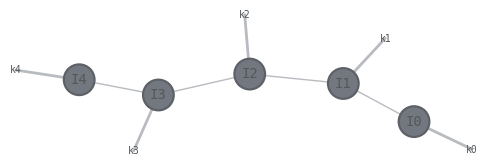

In [369]:
mps.draw()

In [370]:
T

array([[0.99, 0.01],
       [0.1 , 0.9 ]])

## HMM sampling

In [371]:
chi, d = T.shape[0], A.shape[2]
Q = np.array([[p_I_calm, p_X_calm, p_Y_calm, p_Z_calm],
              [p_I_storm, p_X_storm, p_Y_storm, p_Z_storm]])
# Q = np.array([[p_I_storm, p_X_storm, p_Y_storm, p_Z_storm],
#               [p_I_calm, p_X_calm, p_Y_calm, p_Z_calm]])

model = CategoricalHMM(n_components=chi, init_params="")
model.startprob_ = l
model.transmat_ = T
model.emissionprob_ = Q

samples = model.sample(n_samples=100)
obs, states = samples
obs.flatten()

array([0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 3, 0, 0, 0, 1, 1])